In [1]:
import ipywidgets as widgets
import pyarrow as pa
import numpy as np
import pyarrow.parquet as pq
import matplotlib.pyplot as plt
import base64
from io import BytesIO
from PIL import Image
import json

In [13]:
path = "viewfs://hadoop-lt-cluster/home/reco_wl/mpi/luoxinchen/recovlm_dataset_stage2/SyntheticOCR_EN"
fs = pa.hdfs.connect(user='mpi')
files = fs.ls(path)
files = [x for x in files if x.endswith("parquet")]

/tmp/ipykernel_58839/4183922117.py:2: FutureWarning: pyarrow.hdfs.connect is deprecated as of 2.0.0, please use pyarrow.fs.HadoopFileSystem instead.
  fs = pa.hdfs.connect(user='mpi')


In [14]:
x = np.random.choice(files)
print(x)
df = pq.read_table(x).to_pandas()

viewfs://hadoop-lt-cluster/home/reco_wl/mpi/luoxinchen/recovlm_dataset_stage2/SyntheticOCR_EN/rank-62-a23a5d0c-da2a-11ef-a952-946daee9122e.parquet


source=SyntheticOCR_EN, img_nums=1, messages=[{'role': 'user', 'content': [{'type': 'image', 'image': '0.jpg'}, {'type': 'text', 'text': 'Extract all the text from the image, ignoring any background distractions or noise. Ensure the text appears in a natural reading order and provide the output as plain text.'}]}, {'role': 'assistant', 'content': [{'type': 'text', 'text': 'perclose euxanthate heirs buxeous empty-vaulted Coarsegold frontages underbowser laitances'}]}], segments=None
message sample. Content:
[{"role": "user", "content": [{"type": "image", "image": "0.jpg"}, {"type": "text", "text": "Extract all the text from the image, ignoring any background distractions or noise. Ensure the text appears in a natural reading order and provide the output as plain text."}]}, {"role": "assistant", "content": [{"type": "text", "text": "perclose euxanthate heirs buxeous empty-vaulted Coarsegold frontages underbowser laitances"}]}]
[user]: 


'0.jpg'

(774, 32)

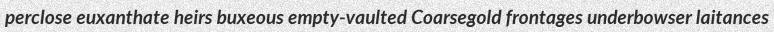

Extract all the text from the image, ignoring any background distractions or noise. Ensure the text appears in a natural reading order and provide the output as plain text.
----------
[assistant]: perclose euxanthate heirs buxeous empty-vaulted Coarsegold frontages underbowser laitances
----------


In [22]:
def decode_base64_image(base64_string):
    # 解码base64字符串并返回PIL图像对象
    image_data = base64.b64decode(base64_string)
    image = Image.open(BytesIO(image_data))
    return image

def format_messages(messages, images):
    for msg in messages:
        msg_content = f"[{msg['role']}]: "
        if isinstance(msg["content"], str):
            msg_content += msg["content"]
            continue
        for content in msg["content"]:
            if content["type"] == "image":
                if msg_content != "":
                    print(msg_content)
                    msg_content = ""
                name = content["image"]
                image = images[name]
                display(name, image.size, image)
            elif content["type"] == "text":
                msg_content += content["text"]
            elif content["type"] == "video":
                print(content)
        if msg_content != "":
            print(msg_content)
        print("-" * 10)

def format_segments(segments, images):
    for seg in segments:
        if seg["type"] == "text":
            print(seg["text"] + "\n")
        elif seg["type"] == "image":
            name = seg["image"]
            image = images[name]
            display(name, image.size, image)
            

def display_sample(sample):
    source = sample['source']
    images = json.loads(sample.pop('images'))
    messages = None if sample['messages'] is None else json.loads(sample['messages'])
    segments = None if sample['segments'] is None else json.loads(sample['segments'])
    for name, base64_string in images.items():
        image = decode_base64_image(base64_string)
        images[name] = image

    print(f"source={source}, img_nums={len(images)}, messages={messages}, segments={segments}")
    if segments is not None:
        print("segments sample. Content:")
        print(sample['segments'])
        print("=" * 10)
        format_segments(segments, images)
    elif messages is not None:
        print("message sample. Content:")
        print(sample['messages'])
        print("=" * 10)
        format_messages(messages, images)

display_sample(df.sample().iloc[0].to_dict())

In [ ]:
df